# GROUP 2
# PROJECT : AI-POWERED JOB SCAM DETECTION SYSTEM

##  GROUP MEMBERS
1. ### BRIANNAH CHELANGAT
2. ### CHRISTOPHER KARUIKI
3. ### MELISA ACHIENG
4. ### CLEOPAS KARANJA
5. ### ALEX KINYUA

## 1. Business Understanding
### 1.1 Business Problem
Kenya has experienced a significant rise in fraudulent job advertisements, particularly targeting unemployed youth seeking local and overseas employment opportunities. Fraudsters use fake job postings to:<br>

> Collect application fees<br>
> Steal personal information<br>
> Conduct financial scams<br>
> Facilitate human trafficking through fake overseas jobs<br>

Current interventions are mainly reactive, where agencies are investigated or blacklisted after victims have already suffered losses. Job seekers lack a reliable tool that can assess the legitimacy of a job advertisement before they apply or pay money.

### 1.2 Business Objectives

The project seeks to:<br>

### Objective 1: Detect Fraudulent Job Advertisements
Develop a machine learning model that classifies job advertisements as: Genuine (0) or Fraudulent (1) using textual and structured job-posting information.<br>

### Objective 2: Identify Scam Patterns
Use NLP techniques to identify common scam indicators such as: Urgent hiring language, Upfront payment requests, Poorly written descriptions, Unrealistic salaries and Suspicious contact information.<br>

### Objective 3: Integrate Kenyan Government Verification<br>
The system should verify:<br>
> Whether a recruitment agency is licensed<br>
> Whether the agency appears on government blacklists<br>
> Whether the company exists in government records<br>

### Objective 4: Explain Predictions
Instead of only predicting fraud, the system should explain why a posting was flagged with reasons like ; Agency not found in NEA registry, Requests visa processing fee,Unrealistic overseas salary,Uses urgency phrases such as "Apply Immediately" e.t.c<br>

### 1.3 Stakeholders
Primary stakeholders<br>
> 1. Job Seekers
 Use the system before applying for jobs.Helps them to avoid scams, protect personal data and avoid financial losses.<br>
 > 2. Government Agencies
 Government agencies like National Employment Authority (NEA), Ministry of Labour and DCI will use the system to detct scam patterns earlier and monitor suspicious agencies.<br>
 > 3. Recruitment Platforms
 Recruitment platforms like BrighterMonday, Fuzu and MyJobsInKenya will use the platform to automatically flag suspicious suspicious job posts before ublication.<br>

 ### 1.4 Success Criteria
The project will be considered successful if it achieves:<br>
High Recall : The model should identify most scam jobs.<br>
Recall is important because missing a scam may result in real-world harm to users.<br>
Good Precision : Legitimate jobs should not be incorrectly flagged too often.<br>
High F1 Score : Balances precision and recall.<br>
Strong ROC-AU : To measure overall classification performance.<br>
Explainability : Predictions should be understandable to non-technical users.<br>

## 2. Data Understanding
### 2.1 Data Sources
Primary Dataset: DIFrauD / EMSCAD<br>
Dataset used for training had the following characteristics;<br>
> 14,295 job postings<br>
> 599 fraudulent postings<br>
> 13,696 legitimate postings<br>

Label:<br>
> 1 = Fraudulent<br>
> 0 = Legitimate<br>
Kenya Specicific Verifcation Data:<br>
NEA Recruitment Agency Register : Used to determine whether an agency is licensed.<br>
DCI Blacklisted Agencies : Used to identify agencies involved in fraud.<br>
Government Advisories : Used to identify emerging scam patterns.<br>
Local Job Boards like ; BrighterMonday, Fuzu and MyJobsInKenya Used for future model adaptation.<br>

### 2.2 Dataset Variables
The project satandardizes job advertisements into a common sructure such as;<br>
Variable    Description<br>
posting_id - Unique job identifier<br>
title -	Job title<br>
description - Job description<br>
company -	Hiring company<br>
agency - Recruitment agency<br>
location - Job location<br>
salary - Salary offered<br>
employment_type - Full-time, part-time, contract<br>
email - Contact email<br>
source - Source platform<br>
country - Job destination country<br>
is_overseas - Overseas job indicator<br>
fraud_label - Target variable<br>
### 2.3 Exploratory Data Analysis (EDA)

Key questions:
Class Distribution : How many jobs are fraud versus genuine?<br>
Missing Values : Which variables contain missing data?<br>
Salary Analysis : Do scam jobs offer unusually high salaries?<br>
Text Analysis : Which words frequently appear in scam advertisements? Examples: urgent, visa, fee, immediate and no experience<br>
Country Analysis : Which overseas destinations are most commonly associated with suspicious advertisements?<br>

## 3. Data Preparation
### 3.1 Data Cleaning
Remove Duplicates : Many scam ads are reposted multiple times.<br>
Handle Missing Values like Missing salary, Missing company name and  Missing agency information<br>
Standardize Text by converting : Uppercase to lowercase, Remove punctuation, Remove HTML tags and Remove special characters.<br>
### 3.2 Feature Engineering
A. Text Features (NLP) : Transform text into machine-readable features.<br>
Methods:
TF-IDF : Measures the importance of words in a job advertisement.<br>
Word Embeddings : Capture semantic meaning.<br>
Sentence Embeddings : Used in transformer-based models.<br>
B. Rule-Based Features <br>
Examples:<br>
Rule	Flag
Contains  "pay registration fee" - 1<br>
Contains "visa processing fee" - 1<br>
Uses Gmail instead of company domain - 1<br>
Unrealistic salary - 1<br>
Missing company information - 1<br>
C. Government Verification Features<br>
Examples:<br>
Feature	    Meaning<br>
agency_verified - Agency exists in NEA registry<br>
agency_blacklisted - Agency appears on blacklist<br>
company_verified - Company exists<br 

## 4. Modeling

The modelling scope was narrowed to efficient, interpretable linear models suitable for sparse text features and deployment. This notebook trains Logistic Regression and LinearSVC. XGBoost, neural networks, BERT, and Random Forest were not trained here.

## 5. Evaluation
Key Activities:<br>
Evaluate model performance.<br>
Assess business impact.<br>
Check if objectives are met.<br>

Questions Answered<br>
Does the model perform well?<br>
Does it meet business needs?<br>
Is it ready for deployment?<br>

Business:<br>
Can the model prevent users from falling for scams?<br>
Are explanations understandable?<br>
Deliverables<br>
Evaluation report<br>
Recommendations<br>
Deployment decision<br>

## 6. Deployment

The notebook exports the single sklearn model pipeline used by the FastAPI service. Registry verification, deterministic rule explanations, API routing, authentication, and dashboard behavior are implemented elsewhere in the deployed application.

# Dataset Integration (2-Class, Merged)

This notebook standardizes the available job-posting data, harmonizes labels, and exports one modelling-ready dataset.

**Target scheme: `is_fraud` has two classes:**

- **0: Legitimate**
- **1: Fraudulent or Fraud-risk**

**Important:** real job-board postings are not automatically labeled legitimate. Their `is_fraud` remains `NaN` unless the project team approves that policy. EMSCAD provides real labels, while synthetic data provides generated training scenarios.

This notebook builds the fraud-detection model for job postings, alongside the government entity-verification check. The model outputs a fraud-risk probability.

In [2]:
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)


## 1. Load the datasets

The available source files are loaded directly from the portable raw-data directory.

In [3]:
from pathlib import Path

# Find the folder containing the datasets
files = [
    "fake_job_postings.csv",
    "fuzu_kenya_jobs.csv",
    "pigiame_jobs_full.csv",
    "corporatestaffing_jobs_full.csv",
    "brightermonday_kenya_jobs.csv",
    "jobwebkenya_jobs_full.csv",
    "synthetic_40k.csv"
]

base = Path.cwd()

while base != base.parent:
    if (base / "fake_job_postings.csv").exists():
        break
    if (base / "data" / "raw" / "fake_job_postings.csv").exists():
        base = base / "data" / "raw"
        break
    base = base.parent

RAW = base

print("Dataset folder:", RAW)

df_fake = pd.read_csv(RAW / "fake_job_postings.csv")
df_fuzu = pd.read_csv(RAW / "fuzu_kenya_jobs.csv")
df_pigia = pd.read_csv(RAW / "pigiame_jobs_full.csv")
df_corp = pd.read_csv(RAW / "corporatestaffing_jobs_full.csv")
df_bm = pd.read_csv(RAW / "brightermonday_kenya_jobs.csv")
df_jobweb = pd.read_csv(RAW / "jobwebkenya_jobs_full.csv")
df_synthetic = pd.read_csv(RAW / "synthetic_40k.csv")

datasets = {
    "Fake Job Postings": df_fake,
    "Fuzu Kenya": df_fuzu,
    "PigiaMe Kenya": df_pigia,
    "Corporate Staffing Kenya": df_corp,
    "BrighterMonday Kenya": df_bm,
    "JobWeb Kenya": df_jobweb,
    "Synthetic Augmentation": df_synthetic,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Dataset folder: c:\Users\chris\Desktop\Project
Fake Job Postings: (17880, 18)
Fuzu Kenya: (666, 7)
PigiaMe Kenya: (1500, 8)
Corporate Staffing Kenya: (3988, 7)
BrighterMonday Kenya: (1964, 13)
JobWeb Kenya: (5323, 9)
Synthetic Augmentation: (40000, 13)


## 2. Clean column names

In [4]:
for df in datasets.values():
    df.columns = df.columns.str.strip()

for name, df in datasets.items():
    print(f'\n{name}')
    print(df.columns.tolist())



Fake Job Postings
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Fuzu Kenya
['title', 'company', 'location', 'salary_range', 'tags', 'description', 'source_url']

PigiaMe Kenya
['title', 'company', 'work_type', 'location', 'salary_range', 'posted', 'description', 'source_url']

Corporate Staffing Kenya
['title', 'industry', 'salary_range', 'location', 'deadline', 'description', 'source_url']

BrighterMonday Kenya
['title', 'company', 'category', 'location', 'work_type', 'salary_range', 'min_qualification', 'experience_level', 'experience_length', 'language_requirement', 'working_hours', 'description', 'source_url']

JobWeb Kenya
['title', 'company', 'location', 'state', 'job_type', 'job_category', 'closing_date', 'description', 'source_url']

Synthetic Au

## 3. Standardize each dataset into a common schema

Each source is mapped into the same set of columns. Fields the source
doesn't have are filled with `NaN` rather than guessed.


In [5]:
# 1. Fake Job Postings (EMSCAD) -- has genuine ground-truth labels
df_fake_std = pd.DataFrame({
    'title': df_fake['title'],
    'company': df_fake['company_profile'],
    'location': df_fake['location'],
    'industry_category': df_fake['industry'],
    'work_type': df_fake['employment_type'],
    'salary_range': df_fake['salary_range'],
    'experience_level': df_fake['required_experience'],
    'min_qualification': df_fake['required_education'],
    'description': df_fake['description'],
    'requirements': df_fake['requirements'],
    'source_url': np.nan,
    'source_platform': 'Fake Job Postings Dataset',
    'is_fraud': df_fake['fraudulent'],   # real label, recovered from the original column
    'data_source': 'original',
})

# 2. Fuzu Kenya -- no fraud label available
df_fuzu_std = pd.DataFrame({
    'title': df_fuzu['title'],
    'company': df_fuzu['company'],
    'location': df_fuzu['location'],
    'industry_category': df_fuzu['tags'],
    'work_type': np.nan,
    'salary_range': df_fuzu['salary_range'],
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df_fuzu['description'],
    'requirements': np.nan,
    'source_url': df_fuzu['source_url'],
    'source_platform': 'Fuzu Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})

# 3. PigiaMe Kenya -- no fraud label available
df_pigia_std = pd.DataFrame({
    'title': df_pigia['title'],
    'company': df_pigia['company'],
    'location': df_pigia['location'],
    'industry_category': np.nan,
    'work_type': df_pigia['work_type'],
    'salary_range': df_pigia['salary_range'],
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df_pigia['description'],
    'requirements': np.nan,
    'source_url': df_pigia['source_url'],
    'source_platform': 'PigiaMe Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})

# 4. Corporate Staffing Kenya -- no fraud label available
df_corp_std = pd.DataFrame({
    'title': df_corp['title'],
    'company': np.nan,
    'location': df_corp['location'],
    'industry_category': df_corp['industry'],
    'work_type': np.nan,
    'salary_range': df_corp['salary_range'],
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df_corp['description'],
    'requirements': np.nan,
    'source_url': df_corp['source_url'],
    'source_platform': 'Corporate Staffing Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})


In [6]:
# 5. BrighterMonday Kenya -- no fraud label available
df_bm_std = pd.DataFrame({
    'title': df_bm['title'],
    'company': df_bm['company'],
    'location': df_bm['location'],
    'industry_category': df_bm['category'],
    'work_type': df_bm['work_type'],
    'salary_range': df_bm['salary_range'],
    'experience_level': df_bm['experience_level'],
    'min_qualification': df_bm['min_qualification'],
    'description': df_bm['description'],
    'requirements': np.nan,
    'source_url': df_bm['source_url'],
    'source_platform': 'BrighterMonday Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})


In [7]:
# 6. JobWeb Kenya -- no fraud label available
df_jobweb_std = pd.DataFrame({
    'title': df_jobweb['title'],
    'company': df_jobweb['company'],
    'location': df_jobweb['location'],
    'industry_category': df_jobweb['job_category'],
    'work_type': df_jobweb['job_type'],
    'salary_range': np.nan,
    'experience_level': np.nan,
    'min_qualification': np.nan,
    'description': df_jobweb['description'],
    'requirements': np.nan,
    'source_url': df_jobweb['source_url'],
    'source_platform': 'JobWeb Kenya',
    'is_fraud': np.nan,
    'data_source': 'original',
})


## 4. Standardize the synthetic dataset

`synthetic_40k.csv` already uses the standard column names and the 0/1/2 label scheme, so this is a pass-through with a `data_source` tag.

In [8]:
df_synthetic_std = pd.DataFrame({
    'title': df_synthetic['title'],
    'company': df_synthetic['company'],
    'location': df_synthetic['location'],
    'industry_category': df_synthetic['industry_category'],
    'work_type': df_synthetic['work_type'],
    'salary_range': df_synthetic['salary_range'],
    'experience_level': df_synthetic['experience_level'],
    'min_qualification': df_synthetic['min_qualification'],
    'description': df_synthetic['description'],
    'requirements': df_synthetic['requirements'],
    'source_url': np.nan,
    'source_platform': 'Synthetic',
    'is_fraud': df_synthetic['is_fraud'],   # already 0 / 1 / 2 -- no remapping needed
    'data_source': 'synthetic',
})


## 5. Combine all datasets

Every available source now shares the standardized schema, so the rows are stacked.

In [9]:
final_df = pd.concat(
    [df_fake_std, df_fuzu_std, df_pigia_std, df_corp_std, df_bm_std, df_jobweb_std, df_synthetic_std],
    ignore_index=True
)

print('Combined shape:', final_df.shape)
final_df.head(3)


Combined shape: (71321, 14)


,title,company,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,source_url,source_platform,is_fraud,data_source
0,Marketing Intern,"We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, con...","US, NY, New York",NaN,Other,NaN,Internship,NaN,"Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and cu...",Experience with content management systems a major plus (any blogging counts!)Familiar with the ...,NaN,Fake Job Postings Dataset,0.0,original
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production Service.90 Seconds is the worlds Cloud Video Produ...","NZ, , Auckland",Marketing and Advertising,Full-time,NaN,Not Applicable,NaN,Organised - Focused - Vibrant - Awesome!Do you have a passion for customer service? Slick typing...,"What we expect from you:Your key responsibility will be to communicate with the client, 90 Secon...",NaN,Fake Job Postings Dataset,0.0,original
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions that meet the needs of companies across the Private ...,"US, IA, Wever",NaN,NaN,NaN,NaN,NaN,"Our client, located in Houston, is actively seeking an experienced Commissioning Machinery Assis...",Implement pre-commissioning and commissioning procedures for rotary equipment.Execute all activi...,NaN,Fake Job Postings Dataset,0.0,original


We combine labeled EMSCAD data, synthetic Kenya-market postings, and unlabeled job-board data. A real labeled holdout is carved out before modelling and reserved for final evaluation.

## 6. Harmonize `is_fraud` into three classes

EMSCAD labels are mapped into the shared three-class description, synthetic labels pass through, and unlabeled job-board rows remain `NaN`. The modelling section later combines Suspicious and Fraudulent into binary Fraud-risk.

In [10]:
final_df['is_fraud'] = pd.to_numeric(final_df['is_fraud'], errors='coerce')

# Only the EMSCAD rows are still on the old binary scheme at this point;
# remap just that source so the Kenya-board NaNs and the synthetic 0/1/2
# values are left untouched.
is_emscad = final_df['source_platform'] == 'Fake Job Postings Dataset'
final_df.loc[is_emscad, 'is_fraud'] = final_df.loc[is_emscad, 'is_fraud'].map({0: 0, 1: 2})

class_names = {0: 'Legitimate', 1: 'Suspicious', 2: 'Fraudulent / Scam'}

print('is_fraud value counts after harmonization:')
print(final_df['is_fraud'].value_counts(dropna=False).sort_index())


is_fraud value counts after harmonization:
is_fraud
0.0    39871
1.0    11429
2.0     6580
NaN    13441
Name: count, dtype: int64


## 7. Inspect fraud labels by source

A key sanity check before modelling: confirms the Kenya job-board sources
are still unlabeled (`NaN`), EMSCAD has real 0/2 labels, and the synthetic
data carries all three classes.


In [11]:
fraud_by_source = pd.crosstab(
    final_df['source_platform'],
    final_df['is_fraud'],
    dropna=False
)
display(fraud_by_source)


is_fraud,0.0,1.0,2.0,NaN
source_platform,,,,
BrighterMonday Kenya,0,0,0,1964
Corporate Staffing Kenya,0,0,0,3988
Fake Job Postings Dataset,17014,0,866,0
Fuzu Kenya,0,0,0,666
JobWeb Kenya,0,0,0,5323
PigiaMe Kenya,0,0,0,1500
Synthetic,22857,11429,5714,0


## 8. Optional labeling decision

This remains commented out deliberately. Uncomment only if the project team explicitly approves treating unlabeled job-board postings as presumed legitimate.

In [12]:
# Example ONLY -- uncomment after the labeling policy has been approved.

# legitimate_platforms = [
#     'Fuzu Kenya',
#     'PigiaMe Kenya',
#     'Corporate Staffing Kenya',
#     'BrighterMonday Kenya',
#     'JobWeb Kenya',
# ]
# final_df.loc[
#     final_df['source_platform'].isin(legitimate_platforms),
#     'is_fraud'
# ] = 0


## 9. Remove exact duplicate postings

In [13]:
before = len(final_df)

final_df = final_df.drop_duplicates(
    subset=['title', 'company', 'location', 'description'],
    keep='first'
).reset_index(drop=True)

after = len(final_df)
print('Rows before duplicate removal:', before)
print('Rows after duplicate removal:', after)
print('Duplicates removed:', before - after)


Rows before duplicate removal: 71321
Rows after duplicate removal: 70302
Duplicates removed: 1019


## 10. Full dataset summary (before trimming metadata columns)

In [14]:
print('Shape:', final_df.shape)

print('\nSource platform distribution:')
display(final_df['source_platform'].value_counts())

print('\nData source distribution:')
display(final_df['data_source'].value_counts())

print('\nFraud label distribution:')
display(final_df['is_fraud'].value_counts(dropna=False).sort_index())

print('\nNamed classes:')
for label, name in class_names.items():
    count = (final_df['is_fraud'] == label).sum()
    print(f'{label}: {name} -> {count:,}')
print(f"NaN / unknown labels -> {final_df['is_fraud'].isna().sum():,}")


Shape: (70302, 14)

Source platform distribution:


source_platform
Synthetic                    39733
Fake Job Postings Dataset    17417
JobWeb Kenya                  5257
Corporate Staffing Kenya      3982
BrighterMonday Kenya          1954
PigiaMe Kenya                 1293
Fuzu Kenya                     666
Name: count, dtype: int64


Data source distribution:


data_source
synthetic    39733
original     30569
Name: count, dtype: int64


Fraud label distribution:


is_fraud
0.0    39219
1.0    11426
2.0     6505
NaN    13152
Name: count, dtype: int64


Named classes:
0: Legitimate -> 39,219
1: Suspicious -> 11,426
2: Fraudulent / Scam -> 6,505
NaN / unknown labels -> 13,152


The metadata columns are dropped after source-level inspection. Source provenance remains available in `final_df` before this step.

In [15]:
required_columns = [
    'title', 'company', 'location', 'industry_category', 'work_type',
    'salary_range', 'experience_level', 'min_qualification',
    'description', 'requirements', 'is_fraud'
]

model_df = final_df[required_columns].copy()

print('Final columns:')
print(model_df.columns.tolist())

for col in ['source_url', 'source_platform', 'data_source']:
    assert col not in model_df.columns, f'{col} was not removed.'
print('\nMetadata-column check passed.')


Final columns:
['title', 'company', 'location', 'industry_category', 'work_type', 'salary_range', 'experience_level', 'min_qualification', 'description', 'requirements', 'is_fraud']

Metadata-column check passed.


## 12. Missing-value overview (modelling columns)

In [16]:
missing_summary = (
    model_df.isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
    .to_frame('missing_percent')
)
display(missing_summary)


,missing_percent
salary_range,31.60
min_qualification,27.58
experience_level,26.10
requirements,22.46
is_fraud,18.71
work_type,14.39
company,12.62
industry_category,8.69
location,6.46
description,1.84


## 13. Preview the final dataset

In [17]:
display(model_df.head())
display(model_df.sample(min(10, len(model_df)), random_state=42))


,title,company,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,is_fraud
0,Marketing Intern,"We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, con...","US, NY, New York",NaN,Other,NaN,Internship,NaN,"Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and cu...",Experience with content management systems a major plus (any blogging counts!)Familiar with the ...,0.0
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production Service.90 Seconds is the worlds Cloud Video Produ...","NZ, , Auckland",Marketing and Advertising,Full-time,NaN,Not Applicable,NaN,Organised - Focused - Vibrant - Awesome!Do you have a passion for customer service? Slick typing...,"What we expect from you:Your key responsibility will be to communicate with the client, 90 Secon...",0.0
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions that meet the needs of companies across the Private ...,"US, IA, Wever",NaN,NaN,NaN,NaN,NaN,"Our client, located in Houston, is actively seeking an experienced Commissioning Machinery Assis...",Implement pre-commissioning and commissioning procedures for rotary equipment.Execute all activi...,0.0
3,Account Executive - Washington DC,Our passion for improving quality of life through geography is at the heart of everything we do....,"US, DC, Washington",Computer Software,Full-time,NaN,Mid-Senior level,Bachelor's Degree,THE COMPANY: ESRI – Environmental Systems Research InstituteOur passion for improving quality of...,"EDUCATION: Bachelor’s or Master’s in GIS, business administration, or a related field, or equiva...",0.0
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Capital Management Consulting firm headquartered in M...,"US, FL, Fort Worth",Hospital & Health Care,Full-time,NaN,Mid-Senior level,Bachelor's Degree,"JOB TITLE: Itemization Review ManagerLOCATION: Fort Worth, TX ...","QUALIFICATIONS:RN license in the State of TexasDiploma or Bachelors of Science in Nursing, requi...",0.0


,title,company,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,is_fraud
49778,Accounts Assistant,Swift HR Consultants Ltd,Thika,Retail,Full-time,"KES 95,000/month",No experience required,Diploma,Swift HR Consultants Ltd is looking for a Accounts Assistant to work in Thika. Maintain accurate...,Bachelor's degree required. 1-3 years preferred.,1.0
19312,"Programme Officer, BIOPAMA Action Component",NaN,PigiaMe,NaN,Full time,NaN,NaN,NaN,NaN,NaN,NaN
8053,Python Backend Developer,AGOGO creates a personalized audio channel by bringing together your favorite programming -- new...,"US, CA, San Francisco",Computer Software,Full-time,NaN,NaN,NaN,About AGOGOAGOGO is a personalized audio service that brings together your favorite programming ...,"The Ideal CandidateYou have a solid foundation in computer science, algorithms, and software des...",0.0
49928,Administrative Assistant,Jubilee Insurance Group,Kisii,Banking & Finance,Full-time,"KES 98,000/month",No experience required,Certificate,Jubilee Insurance Group is looking for a Administrative Assistant to work in Kisii. Coordinate w...,KCSE certificate required. 1-3 years preferred.,1.0
3186,Social Media Research Analyst,"BaaSSocial Media Marketing with IntelligenceΓια μια ολοκληρωμένη παρουσία στα Social Media, τα β...","GR, I, Athens",Marketing and Advertising,Full-time,NaN,Mid-Senior level,NaN,Key Responsibilities:Social Media Insights Analysis (Monitoring &amp; Reporting)Utilize Social M...,"Qualifications:Proficiency in social media monitoring, analytics and reporting, very high attent...",0.0
13661,PHP Developer,NaN,"CA, BC, Prince Rupert",Human Resources,Full-time,30-50,Mid-Senior level,Unspecified,seeking a strong php developer who is uber up on 5.2 and can handle the following:Let me give yo...,strong background in architecture and development with servers mixed in.,0.0
67001,Driver (Overseas),Vision HR Consultants Ltd,Oman,Hospitality,Full-time,USD 665/month,Entry level,Bachelor's degree,Vision HR Consultants Ltd is looking for a Driver (Overseas) to work in Oman. Assist in the dail...,Certificate required. No experience required preferred.,1.0
34015,Receptionist,Bamburi Cement,Mombasa,Banking & Finance,Full-time,"KES 37,000/month",Entry level,Bachelor's degree,Bamburi Cement is seeking a qualified Receptionist to join our team in Mombasa. Provide excellen...,Diploma required. No experience required preferred.,0.0
41327,Marketing Assistant,Jubilee Insurance,Nairobi,Healthcare,Contract,"KES 54,000/month",1-3 years,Certificate,Jubilee Insurance is seeking a qualified Marketing Assistant to join our team in Nairobi. Collab...,KCSE certificate required. 3-5 years preferred.,0.0
2299,QA Engineer,NaN,NaN,Information Services,Part-time,Oct-15,Associate,Bachelor's Degree,We are looking for a Quality Assurance Engineer to develop and execute exploratory tests as well...,"BS/MS degree in Computer Science, Engineering or a related subject3+ years of experience in soft...",0.0


## 14. Export
next stage : text preprocessing, feature engineering, train/test splitting, and multiclass fraud modelling.


In [18]:
output_file = 'merged_job_scam_3class.csv'
model_df.to_csv(output_file, index=False)
print(f'Saved: {output_file}')


Saved: merged_job_scam_3class.csv


## 15. Data Cleaning - synthetic_40k.csv

In [19]:
df1 = pd.read_csv(RAW /'synthetic_40k.csv')
df1.shape

(40000, 13)

### 15.1 Initial inspection

In [20]:
print('Shape:', df1.shape)
print()
print(df1.dtypes)
print()
display(df1.head(10))

Shape: (40000, 13)

title                 object
company               object
location              object
industry_category     object
work_type             object
salary_range          object
experience_level      object
min_qualification     object
description           object
requirements          object
source_url           float64
source_platform       object
is_fraud               int64
dtype: object



,title,company,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,source_url,source_platform,is_fraud
0,HR Assistant,Vision Manpower Kenya,Kisumu,Insurance,Full-time,"KES 339,000/month",3-5 years,Certificate,"Immediate start, no interview needed! HR Assistant needed in Kisumu. Send KES 3,000 via M-Pesa t...","No qualifications required, immediate hire.",NaN,Synthetic - AjiraCheck,2
1,Receptionist,Naivas Supermarket,Meru,Logistics,Full-time,"KES 35,000/month",Entry level,Certificate,Naivas Supermarket is seeking a qualified Receptionist to join our team in Meru. Collaborate wit...,Certificate required. Entry level preferred.,NaN,Synthetic - AjiraCheck,0
2,Cashier,Naivas Supermarket,Nyeri,Construction,Full-time,"KES 38,000/month",Entry level,Certificate,Naivas Supermarket is seeking a qualified Cashier to join our team in Nyeri. Handle customer inq...,Bachelor's degree required. No experience required preferred.,NaN,Synthetic - AjiraCheck,0
3,Security Guard,Vision HR Consultants Ltd,Qatar,Logistics,Full-time,USD 829/month,1-3 years,Bachelor's degree,Vision HR Consultants Ltd is looking for a Security Guard to work in Qatar. Ensure compliance wi...,Bachelor's degree required. Entry level preferred.,NaN,Synthetic - AjiraCheck,1
4,HR Assistant,Jubilee Insurance,Thika,Logistics,Full-time,"KES 83,000/month",3-5 years,Bachelor's degree,Jubilee Insurance is seeking a qualified HR Assistant to join our team in Thika. Support the tea...,Bachelor's degree required. Entry level preferred.,NaN,Synthetic - AjiraCheck,0
5,Warehouse Supervisor,KenGen,Nairobi,Insurance,Full-time,"KES 43,000/month",Entry level,Diploma,KenGen is seeking a qualified Warehouse Supervisor to join our team in Nairobi. Follow standard ...,KCSE certificate required. 3-5 years preferred.,NaN,Synthetic - AjiraCheck,0
6,Procurement Officer,Equity Bank Kenya,Meru,Retail,Full-time,"KES 48,000/month",1-3 years,Diploma,Equity Bank Kenya is seeking a qualified Procurement Officer to join our team in Meru. Collabora...,Bachelor's degree required. 1-3 years preferred.,NaN,Synthetic - AjiraCheck,0
7,Caregiver,Ready Manpower Limited,Saudi Arabia,Manufacturing,Full-time,USD 741/month,No experience required,Bachelor's degree,Ready Manpower Limited is seeking a qualified Caregiver to join our team in Saudi Arabia. Handle...,KCSE certificate required. Entry level preferred.,NaN,Synthetic - AjiraCheck,0
8,Domestic Worker,Top Level Management Ltd,United Arab Emirates,Telecommunications,Full-time,USD 428/month,3-5 years,KCSE certificate,Top Level Management Ltd is seeking a qualified Domestic Worker to join our team in United Arab ...,Certificate required. 1-3 years preferred.,NaN,Synthetic - AjiraCheck,0
9,Procurement Officer,Prime Manpower Services Ltd,Kisumu,Manufacturing,Contract,"KES 70,000/month",No experience required,KCSE certificate,Prime Manpower Services Ltd is looking for a Procurement Officer to work in Kisumu. Ensure timel...,Bachelor's degree required. 1-3 years preferred.,NaN,Synthetic - AjiraCheck,1


### 15.2 Standardize column names
Removing white space from the header row

In [21]:
df1.columns = df1.columns.str.strip()
print(df1.columns.tolist())

['title', 'company', 'location', 'industry_category', 'work_type', 'salary_range', 'experience_level', 'min_qualification', 'description', 'requirements', 'source_url', 'source_platform', 'is_fraud']


### 15.3 Trimming whitespace in text columns

In [22]:
text_cols_df1 = df1.select_dtypes(include='object').columns.tolist()
print('Text columns:', text_cols_df1)

for col in text_cols_df1:
    df1[col] = df1[col].astype('string').str.strip()

# Verify: count of remaining leading/trailing whitespace per column
ws_check = {col: (df1[col] != df1[col].str.strip()).sum() for col in text_cols_df1}
print('Remaining whitespace issues:', ws_check)

Text columns: ['title', 'company', 'location', 'industry_category', 'work_type', 'salary_range', 'experience_level', 'min_qualification', 'description', 'requirements', 'source_platform']
Remaining whitespace issues: {'title': 0, 'company': 0, 'location': 0, 'industry_category': 0, 'work_type': 0, 'salary_range': 0, 'experience_level': 0, 'min_qualification': 0, 'description': 0, 'requirements': 0, 'source_platform': 0}


`source_url` is null in the local synthetic file and carries no modelling information there, so the cleaning step removes fully null columns.

In [23]:
missing_df1 = df1.isna().mean().mul(100).round(2).sort_values(ascending=False)
display(missing_df1.to_frame('missing_percent'))

fully_null_cols = missing_df1[missing_df1 == 100].index.tolist()
print('Fully-null columns to drop:', fully_null_cols)

df1 = df1.drop(columns=fully_null_cols)
print('Shape after dropping fully-null columns:', df1.shape)

,missing_percent
source_url,100.0
title,0.0
company,0.0
location,0.0
industry_category,0.0
work_type,0.0
salary_range,0.0
experience_level,0.0
min_qualification,0.0
description,0.0


Fully-null columns to drop: ['source_url']
Shape after dropping fully-null columns: (40000, 12)


### 15.5 Validate and cast "is_fraud"

Confirm the label only ever takes the values `0` (legitimate), `1` (suspicious), `2` (fraudulent) before casting to a small nullable integer type. Anything outside that set gets surfaced.

In [24]:
df1['is_fraud'] = pd.to_numeric(df1['is_fraud'], errors='coerce')

unexpected = df1.loc[~df1['is_fraud'].isin([0, 1, 2]), 'is_fraud']
print('Unexpected / non-numeric is_fraud values:', unexpected.unique())

df1['is_fraud'] = df1['is_fraud'].astype('Int8')
print(df1['is_fraud'].value_counts(dropna=False).sort_index())

Unexpected / non-numeric is_fraud values: []
is_fraud
0    22857
1    11429
2     5714
Name: count, dtype: Int64


### 15.6 Duplicate check

In [25]:
exact_dupes = df1.duplicated().sum()
print('Fully-identical duplicate rows:', exact_dupes)

content_key = ['title', 'company', 'location', 'description']
near_dupes = df1[df1.duplicated(subset=content_key, keep=False)]
print('Rows sharing title+company+location+description (salary differs):', len(near_dupes))

conflict_check = near_dupes.groupby(content_key)['is_fraud'].nunique()
print('Groups with conflicting is_fraud labels:', (conflict_check > 1).sum())

before = len(df1)
df1 = df1.drop_duplicates(keep='first').reset_index(drop=True)
print(f'Rows removed as exact duplicates: {before - len(df1)}')

Fully-identical duplicate rows: 0
Rows sharing title+company+location+description (salary differs): 530
Groups with conflicting is_fraud labels: 0
Rows removed as exact duplicates: 0


No fully-identical rows exist. There ARE 530 rows that share the same "title" / "company" / "location" / "description" but a different "salary_range"so these are kept rather than dropped. 

### 15.7 Parse `salary_range` into numeric fields

For modelling, salary text is split into currency, numeric amount, and period. USD amounts are converted to Kenyan shillings using the explicit fixed rate below.

In [26]:
import re

USD_TO_KES = 130  # <- adjust this single constant if a different FX rate is needed

salary_pattern = re.compile(r'^(KES|USD)\s*([\d,]+)\s*/\s*(\w+)$', flags=re.IGNORECASE)

def parse_salary(value):
    if pd.isna(value):
        return pd.Series([np.nan, np.nan, np.nan])
    m = salary_pattern.match(str(value).strip())
    if not m:
        return pd.Series([np.nan, np.nan, np.nan])
    currency, amount, period = m.groups()
    return pd.Series([currency.upper(), float(amount.replace(',', '')), period.lower()])

df1[['salary_currency', 'salary_amount', 'salary_period']] = df1['salary_range'].apply(parse_salary)

unparsed = df1['salary_range'].notna() & df1['salary_currency'].isna()
print('salary_range values that failed to parse:', unparsed.sum())
if unparsed.sum():
    display(df1.loc[unparsed, 'salary_range'].unique()[:10])

df1['salary_amount_kes'] = np.where(
    df1['salary_currency'] == 'USD',
    df1['salary_amount'] * USD_TO_KES,
    df1['salary_amount']
)

print(df1[['salary_range', 'salary_currency', 'salary_amount', 'salary_period', 'salary_amount_kes']].head())

salary_range values that failed to parse: 0
        salary_range salary_currency  salary_amount salary_period  \
0  KES 339,000/month             KES       339000.0         month   
1   KES 35,000/month             KES        35000.0         month   
2   KES 38,000/month             KES        38000.0         month   
3      USD 829/month             USD          829.0         month   
4   KES 83,000/month             KES        83000.0         month   

   salary_amount_kes  
0           339000.0  
1            35000.0  
2            38000.0  
3           107770.0  
4            83000.0  


### 15.8 Validate categorical fields

Full value set for each categorical column so any typo, stray category, or unexpected value is caught before modelling.

In [27]:
categorical_cols_df1 = ['work_type', 'experience_level', 'min_qualification', 'industry_category']

for col in categorical_cols_df1:
    print(f'{col} ({df1[col].nunique()} unique values)')
    print(df1[col].value_counts(dropna=False))
    print()

work_type (2 unique values)
work_type
Full-time    30028
Contract      9972
Name: count, dtype: Int64

experience_level (4 unique values)
experience_level
No experience required    10104
3-5 years                  9981
Entry level                9977
1-3 years                  9938
Name: count, dtype: Int64

min_qualification (4 unique values)
min_qualification
KCSE certificate     10140
Diploma              10024
Certificate           9960
Bachelor's degree     9876
Name: count, dtype: Int64

industry_category (9 unique values)
industry_category
Healthcare            4499
Manufacturing         4496
Retail                4475
Telecommunications    4465
Hospitality           4464
Banking & Finance     4439
Logistics             4425
Insurance             4371
Construction          4366
Name: count, dtype: Int64



### 15.9 Final check and export

In [28]:
print('Final shape:', df1.shape)
print()
print('Remaining missing values:')
display(df1.isna().sum().to_frame('missing_count'))

df1.to_csv('synthetic_40k_clean.csv', index=False)
print("\nSaved: synthetic_40k_clean.csv")
df1.duplicated().sum()

Final shape: (40000, 16)

Remaining missing values:


,missing_count
title,0
company,0
location,0
industry_category,0
work_type,0
salary_range,0
experience_level,0
min_qualification,0
description,0
requirements,0



Saved: synthetic_40k_clean.csv


0

## 16. Data cleaning of the local synthetic augmentation view (`df2`)

In [29]:
df2 = pd.read_csv(RAW /'synthetic_augmentation_postings.csv')
print('Shape:', df2.shape)
print()
print(df2.dtypes)
print()
display(df2.head(3))

Shape: (5000, 14)

posting_id          object
title               object
description         object
company             object
agency             float64
location            object
salary             float64
employment_type     object
email               object
source             float64
country             object
is_overseas         object
is_fraud             int64
data_source         object
dtype: object



,posting_id,title,description,company,agency,location,salary,employment_type,email,source,country,is_overseas,is_fraud,data_source
0,SYN-000000,Customer Service Agent,Salary is commensurate with experience and will be discussed during the interview process. No fe...,"Williams, Nicholson and Davis",NaN,Machakos,NaN,Full-time,browningjason@hamilton.com,NaN,Kenya,No,0,synthetic_augmentation
1,SYN-000001,Data Entry Clerk,We are looking for a Data Entry Clerk to join our team based in Kakamega. The successful candida...,"Martinez, Walker and Burton",NaN,Kakamega,NaN,Part-time,rayrandy@williams.com,NaN,Kenya,No,0,synthetic_augmentation
2,SYN-000002,Sales Representative,Minimum requirements: a diploma or degree in a relevant field and at least 1 years of experience...,"Parker, Cabrera and White",NaN,Kakamega,NaN,Full-time,nathankelley@elliott.com,NaN,Kenya,No,0,synthetic_augmentation


### 16.1 Standardize column names and trim text fields

In [30]:
df2.columns = df2.columns.str.strip()

text_cols_df2 = df2.select_dtypes(include='object').columns.tolist()
print('Text columns:', text_cols_df2)

for col in text_cols_df2:
    df2[col] = df2[col].astype('string').str.strip()

Text columns: ['posting_id', 'title', 'description', 'company', 'location', 'employment_type', 'email', 'country', 'is_overseas', 'data_source']


### 16.2 Missing-value

In [31]:
missing_df2 = df2.isna().mean().mul(100).round(2).sort_values(ascending=False)
display(missing_df2.to_frame('missing_percent'))

fully_null_cols_df2 = missing_df2[missing_df2 == 100].index.tolist()
print('Fully-null columns to drop:', fully_null_cols_df2)
df2 = df2.drop(columns=fully_null_cols_df2)

df2['has_email'] = df2['email'].notna()
df2['email'] = df2['email'].fillna('not_provided')

print('\nShape after cleanup:', df2.shape)
print(df2['has_email'].value_counts())

,missing_percent
agency,100.00
salary,100.00
source,100.00
email,14.84
posting_id,0.00
title,0.00
description,0.00
company,0.00
location,0.00
employment_type,0.00


Fully-null columns to drop: ['agency', 'salary', 'source']

Shape after cleanup: (5000, 12)
has_email
True     4258
False     742
Name: count, dtype: int64


"agency", "salary", and "source" are 100% null across all 5,000 rows and so we drop them.

"email" is missing for ~15% of rows. Rather than dropping those rows, a "has_email" flag is kept and the NaNs are filled with an explicit placeholder instead of silently left blank.

### 16.3 Validate email format
Sanity-check every non-placeholder email against a basic "local@domain.tld" pattern and flag anything that doesn't match instead of assuming the column is clean.

In [32]:
email_pattern = re.compile(r'^[^@\s]+@[^@\s]+\.[^@\s]+$')

real_emails = df2.loc[df2['has_email'], 'email']
invalid_emails = real_emails[~real_emails.str.match(email_pattern)]
print(f'Invalid email formats: {len(invalid_emails)} out of {len(real_emails)}')
if len(invalid_emails):
    display(invalid_emails.head(10))

Invalid email formats: 0 out of 4258


### 16.4 Validate and cast 'is_fraud'

In [33]:
df2['is_fraud'] = pd.to_numeric(df2['is_fraud'], errors='coerce')

unexpected_df2 = df2.loc[~df2['is_fraud'].isin([0, 1, 2]), 'is_fraud']
print('Unexpected / non-numeric is_fraud values:', unexpected_df2.unique())

df2['is_fraud'] = df2['is_fraud'].astype('Int8')
print(df2['is_fraud'].value_counts(dropna=False).sort_index())

Unexpected / non-numeric is_fraud values: []
is_fraud
0    4258
1     535
2     207
Name: count, dtype: Int64


### 16.5 Check zero-variance columns

The local augmentation view includes constant `country` and `is_overseas` fields. They are retained here because their value may vary when other sources are combined.

In [34]:
for col in ['country', 'is_overseas']:
    print(f'{col}: {df2[col].nunique()} unique value(s) -> {df2[col].unique()}')

country: 1 unique value(s) -> <StringArray>
['Kenya']
Length: 1, dtype: string
is_overseas: 1 unique value(s) -> <StringArray>
['No']
Length: 1, dtype: string


### 16.6 Remove duplicate postings

Duplicate checking is performed on the available content fields and the cleaning output reports the rows removed.

In [35]:
content_key_df2 = ['title', 'company', 'location', 'description']

dupe_mask = df2.duplicated(subset=content_key_df2, keep=False)
print('Rows involved in content duplicates:', dupe_mask.sum())
display(df2.loc[dupe_mask, ['posting_id'] + content_key_df2 + ['is_fraud']].sort_values(content_key_df2))
before_df2 = len(df2)
df2 = df2.drop_duplicates(subset=content_key_df2, keep='first').reset_index(drop=True)
print(f'\nRows removed as duplicate postings: {before_df2 - len(df2)}')

Rows involved in content duplicates: 20


,posting_id,title,company,location,description,is_fraud
2055,SYN-002055,Administrative Assistant,Not disclosed,Eldoret,We are looking for a Administrative Assistant to join our team based in Eldoret. The successful ...,1
4341,SYN-004341,Administrative Assistant,Not disclosed,Eldoret,We are looking for a Administrative Assistant to join our team based in Eldoret. The successful ...,1
2226,SYN-002226,Administrative Assistant,Not disclosed,Kakamega,We are looking for a Administrative Assistant to join our team based in Kakamega. The successful...,1
2257,SYN-002257,Administrative Assistant,Not disclosed,Kakamega,We are looking for a Administrative Assistant to join our team based in Kakamega. The successful...,1
4663,SYN-004663,Administrative Assistant,Not disclosed,Kisumu,Salary is commensurate with experience and will be discussed during the interview process. No fe...,1
4769,SYN-004769,Administrative Assistant,Not disclosed,Kisumu,Salary is commensurate with experience and will be discussed during the interview process. No fe...,1
1931,SYN-001931,Delivery Driver,Not disclosed,Kakamega,We are looking for a Delivery Driver to join our team based in Kakamega. The successful candidat...,1
4717,SYN-004717,Delivery Driver,Not disclosed,Kakamega,We are looking for a Delivery Driver to join our team based in Kakamega. The successful candidat...,1
948,SYN-000948,Delivery Driver,Not disclosed,Kisumu,We are looking for a Delivery Driver to join our team based in Kisumu. The successful candidate ...,1
2449,SYN-002449,Delivery Driver,Not disclosed,Kisumu,We are looking for a Delivery Driver to join our team based in Kisumu. The successful candidate ...,1



Rows removed as duplicate postings: 10


### 16.7 Final check and export

In [36]:
print('Final shape:', df2.shape)
print()
print('Remaining missing values:')
display(df2.isna().sum().to_frame('missing_count'))

df2.to_csv('synthetic_augmentation_postings_clean.csv', index=False)
print("\nSaved: synthetic_augmentation_postings_clean.csv")
df2.duplicated().sum()

Final shape: (4990, 12)

Remaining missing values:


,missing_count
posting_id,0
title,0
description,0
company,0
location,0
employment_type,0
email,0
country,0
is_overseas,0
is_fraud,0



Saved: synthetic_augmentation_postings_clean.csv


0

## 17. EXPLORATORY DATA ANALYSIS (EDA)

In This section, we explore the cleaned data and craete visuals to be able to understand our data much better, find simple patterns before feature selection and modelling.

In [37]:
import matplotlib.pyplot as plt

### 17.1 Look at the final dataset

In [38]:
print('Rows:', len(model_df))
print('Columns:', len(model_df.columns))

print('\nColumn types:')
display(model_df.dtypes)

print('\nFirst 5 rows:')
display(model_df.head())

Rows: 70302
Columns: 11

Column types:


title                 object
company               object
location              object
industry_category     object
work_type             object
salary_range          object
experience_level      object
min_qualification     object
description           object
requirements          object
is_fraud             float64
dtype: object


First 5 rows:


,title,company,location,industry_category,work_type,salary_range,experience_level,min_qualification,description,requirements,is_fraud
0,Marketing Intern,"We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, con...","US, NY, New York",NaN,Other,NaN,Internship,NaN,"Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and cu...",Experience with content management systems a major plus (any blogging counts!)Familiar with the ...,0.0
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production Service.90 Seconds is the worlds Cloud Video Produ...","NZ, , Auckland",Marketing and Advertising,Full-time,NaN,Not Applicable,NaN,Organised - Focused - Vibrant - Awesome!Do you have a passion for customer service? Slick typing...,"What we expect from you:Your key responsibility will be to communicate with the client, 90 Secon...",0.0
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions that meet the needs of companies across the Private ...,"US, IA, Wever",NaN,NaN,NaN,NaN,NaN,"Our client, located in Houston, is actively seeking an experienced Commissioning Machinery Assis...",Implement pre-commissioning and commissioning procedures for rotary equipment.Execute all activi...,0.0
3,Account Executive - Washington DC,Our passion for improving quality of life through geography is at the heart of everything we do....,"US, DC, Washington",Computer Software,Full-time,NaN,Mid-Senior level,Bachelor's Degree,THE COMPANY: ESRI – Environmental Systems Research InstituteOur passion for improving quality of...,"EDUCATION: Bachelor’s or Master’s in GIS, business administration, or a related field, or equiva...",0.0
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Capital Management Consulting firm headquartered in M...,"US, FL, Fort Worth",Hospital & Health Care,Full-time,NaN,Mid-Senior level,Bachelor's Degree,"JOB TITLE: Itemization Review ManagerLOCATION: Fort Worth, TX ...","QUALIFICATIONS:RN license in the State of TexasDiploma or Bachelors of Science in Nursing, requi...",0.0


### 17.2 Fraud class distribution

Only rows with a known fraud label are used here.

is_fraud
Legitimate    39219
Suspicious    11426
Fraudulent     6505
Name: count, dtype: int64


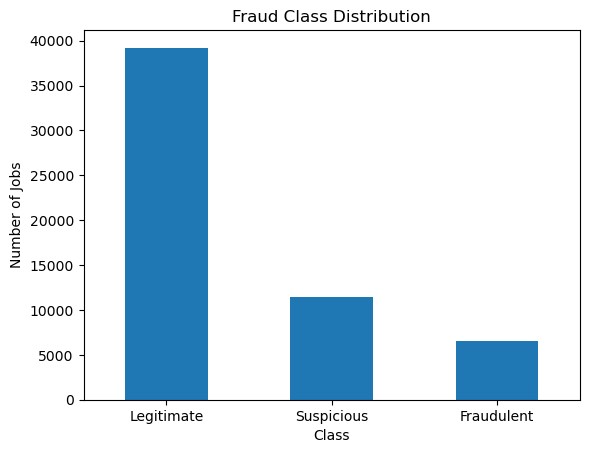

In [67]:
labeled_df = model_df[model_df['is_fraud'].notna()]

class_counts = labeled_df['is_fraud'].value_counts().sort_index()
class_counts.index = class_counts.index.map({
    0: 'Legitimate',
    1: 'Suspicious',
    2: 'Fraudulent'
})

print(class_counts)

class_counts.plot(kind='bar')
plt.title('Fraud Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=0)
plt.show()

The three-class visualization shows the original labels: Legitimate, Suspicious, and Fraudulent.

For the rest of the EDA and modelling process, Suspicious and Fraudulent postings will be combined into one **Fraud Risk** class. This creates a two-class target:

- **Legitimate:** safe-looking job postings
- **Fraud Risk:** suspicious or fraudulent job postings

This approach is used because the deployed system focuses on identifying whether a job posting presents a fraud risk. Combining the two risky classes also makes the later visualizations and binary classification model easier to interpret.


In [68]:
labeled_df['fraud_class'] = labeled_df['is_fraud'].map({
    0: 'Legitimate',
    1: 'Fraud Risk',
    2: 'Fraud Risk'
})

print(labeled_df['fraud_class'].value_counts())


fraud_class
Legitimate    39219
Fraud Risk    17931
Name: count, dtype: int64


C:\Users\chris\AppData\Local\Temp\ipykernel_16100\1720378033.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labeled_df['fraud_class'] = labeled_df['is_fraud'].map({


### 17.3 Labeled and unlabeled records

This visualization compares records with known labels and records without labels. It does not require fraud class conversion.


is_fraud
Labeled      57150
Unlabeled    13152
Name: count, dtype: int64


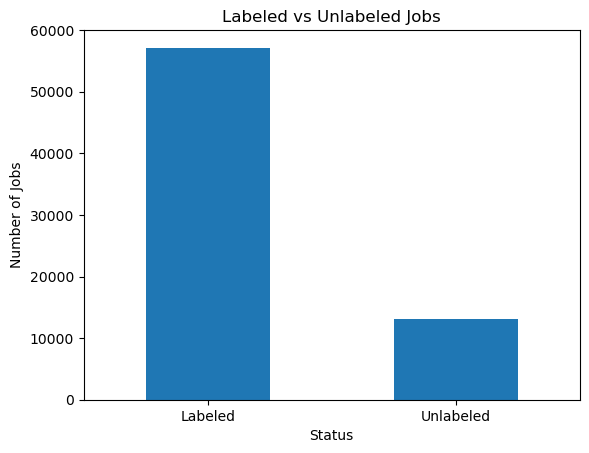

In [69]:
label_status = model_df['is_fraud'].isna().map({
    True: 'Unlabeled',
    False: 'Labeled'
}).value_counts()

print(label_status)

label_status.plot(kind='bar')
plt.title('Labeled vs Unlabeled Jobs')
plt.xlabel('Status')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=0)
plt.show()

### 17.4 Fraud labels by source

This shows which sources contain labels and which are unlabeled.

In [70]:
source_labels = pd.crosstab(
    final_df['source_platform'],
    final_df['is_fraud'],
    dropna=False
)

print(source_labels)


is_fraud                     0.0    1.0   2.0   NaN
source_platform                                    
BrighterMonday Kenya           0      0     0  1954
Corporate Staffing Kenya       0      0     0  3982
Fake Job Postings Dataset  16565      0   852     0
Fuzu Kenya                     0      0     0   666
JobWeb Kenya                   0      0     0  5257
PigiaMe Kenya                  0      0     0  1293
Synthetic                  22654  11426  5653     0


### 17.5 Missing values

In [71]:
missing = model_df.isna().sum().sort_values(ascending=False)
print(missing)

salary_range         22216
min_qualification    19388
experience_level     18350
requirements         15790
is_fraud             13152
work_type            10115
company               8875
industry_category     6108
location              4539
description           1296
title                    1
dtype: int64


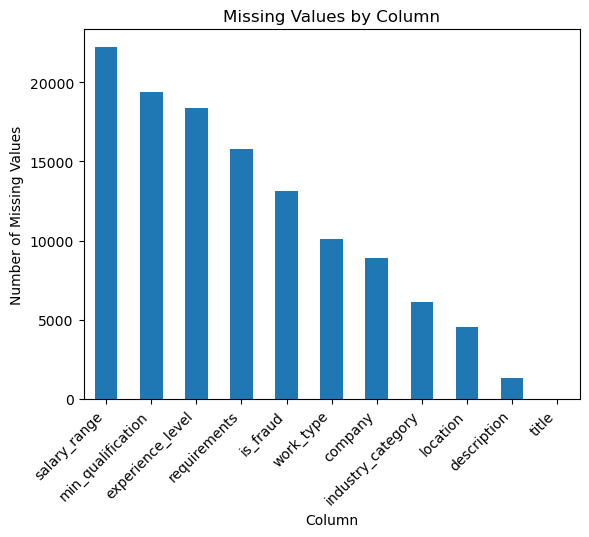

In [72]:
missing[missing > 0].plot(kind='bar')
plt.title('Missing Values by Column')
plt.xlabel('Column')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.show()

### 17.6 Work type

Work type is explored across the full dataset. This visualization is not dependent on the fraud class.


work_type
Full-time     41112
Contract      11604
Missing       10115
Full-Time      4914
Full time      1115
Part-time       754
Temporary       234
Other           223
Internship      218
Part time        10
Part-Time         3
Name: count, dtype: int64


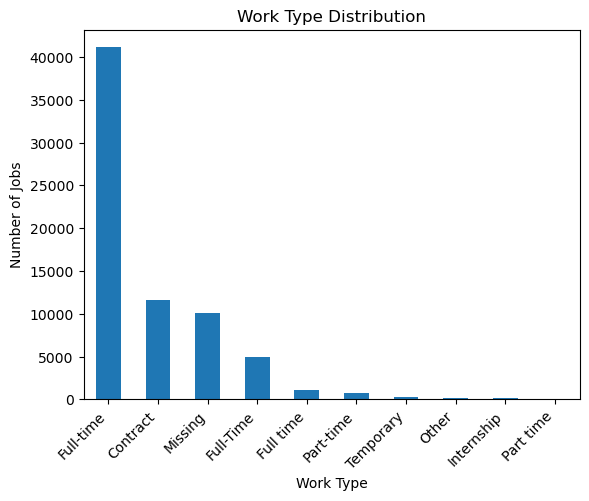

In [73]:
work_type = model_df['work_type'].fillna('Missing').value_counts()
print(work_type)

work_type.head(10).plot(kind='bar')
plt.title('Work Type Distribution')
plt.xlabel('Work Type')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45, ha='right')
plt.show()

### 17.8 Industry category

industry_category
Missing                                6108
Telecommunications                     4732
Retail                                 4670
Hospitality                            4512
Construction                           4498
Manufacturing                          4474
Healthcare                             4471
Insurance                              4459
Banking & Finance                      4401
Logistics                              4397
Information Technology and Services    1693
Computer Software                      1351
Internet                               1049
Education Management                    817
Marketing and Advertising               812
Name: count, dtype: int64


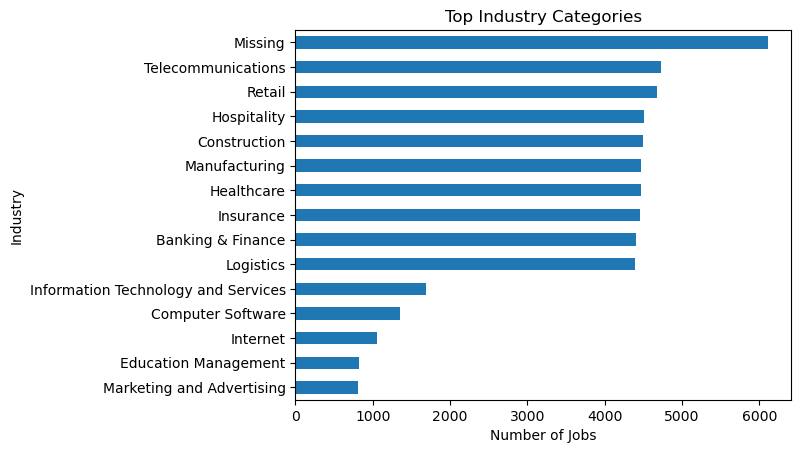

In [74]:
industry = model_df['industry_category'].fillna('Missing').value_counts()

print(industry.head(15))

industry.head(15).sort_values().plot(kind='barh')
plt.title('Top Industry Categories')
plt.xlabel('Number of Jobs')
plt.ylabel('Industry')
plt.show()


### 17.9 Text length

In [75]:
eda_df = model_df.copy()

eda_df['title_length'] = eda_df['title'].fillna('').str.len()
eda_df['description_length'] = eda_df['description'].fillna('').str.len()
eda_df['requirements_length'] = eda_df['requirements'].fillna('').str.len()

print(eda_df[['title_length', 'description_length', 'requirements_length']].describe())

       title_length  description_length  requirements_length
count  70302.000000        70302.000000         70302.000000
mean      24.905081          956.497909           172.502461
std       16.784408         1839.873628           389.247302
min        0.000000            0.000000             0.000000
25%       15.000000          243.000000            38.000000
50%       19.000000          283.000000            47.000000
75%       28.000000         1079.000000            60.000000
max      200.000000       120873.000000         10864.000000


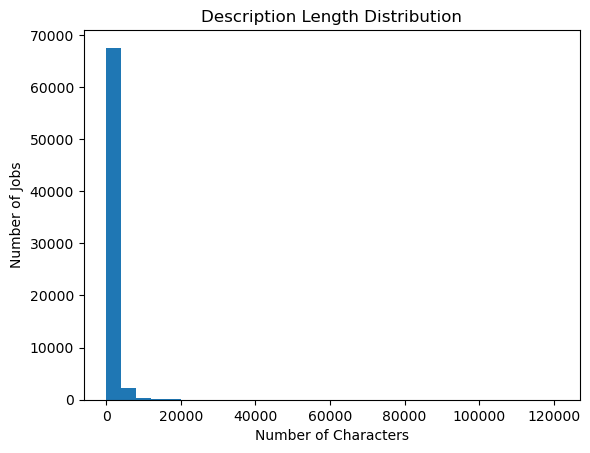

In [76]:
eda_df['description_length'].plot(kind='hist', bins=30)
plt.title('Description Length Distribution')
plt.xlabel('Number of Characters')
plt.ylabel('Number of Jobs')
plt.show()

### 17.10 Description length by fraud class

This visualization compares the average description length between the two binary classes: Legitimate and Fraud Risk.


fraud_class
Legitimate    664.495653
Fraud Risk    276.026212
Name: description_length, dtype: float64


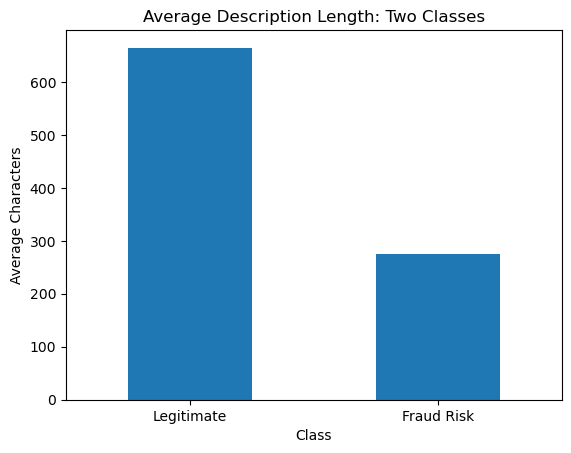

In [77]:
# Two-class average description length

eda_binary = eda_df[eda_df['is_fraud'].notna()].copy()
eda_binary['fraud_class'] = eda_binary['is_fraud'].astype(int).map({
    0: 'Legitimate',
    1: 'Fraud Risk',
    2: 'Fraud Risk'
})

average_length = eda_binary.groupby('fraud_class')['description_length'].mean()
average_length = average_length.reindex(['Legitimate', 'Fraud Risk'])

print(average_length)

average_length.plot(kind='bar')
plt.title('Average Description Length: Two Classes')
plt.xlabel('Class')
plt.ylabel('Average Characters')
plt.xticks(rotation=0)
plt.show()


### 17.11 Salary in the cleaned synthetic 40K data

In [78]:
salary = df1[df1['salary_amount_kes'].notna()]

print('Salary records:', len(salary))
print(salary['salary_amount_kes'].describe())

Salary records: 40000
count     40000.000000
mean     116119.520500
std      111917.522057
min       30000.000000
25%       58000.000000
50%       78000.000000
75%      104650.000000
max      584870.000000
Name: salary_amount_kes, dtype: float64


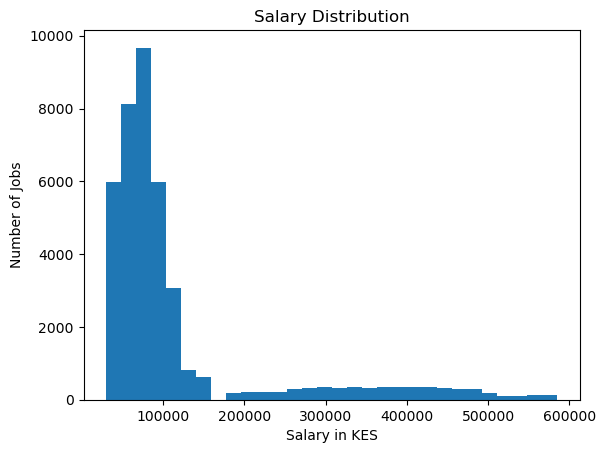

In [79]:
salary['salary_amount_kes'].plot(kind='hist', bins=30)
plt.title('Salary Distribution')
plt.xlabel('Salary in KES')
plt.ylabel('Number of Jobs')
plt.show()

### 17.12 Salary by binary fraud class

The Suspicious and Fraudulent records are combined into the Fraud Risk class before comparing average salary.


fraud_class
Legitimate     68522.849893
Fraud Risk    179580.822493
Name: salary_amount_kes, dtype: float64


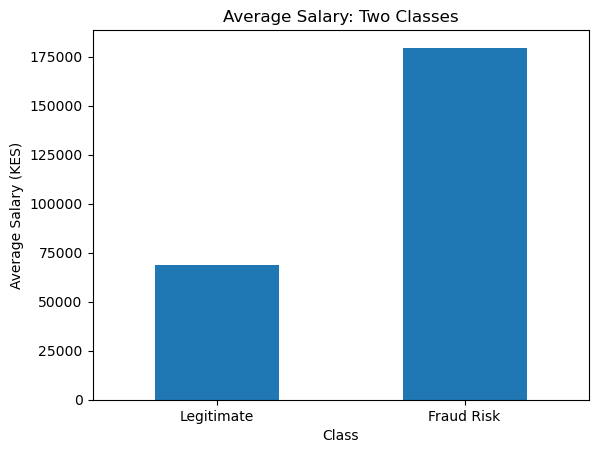

In [80]:
# Two-class average salary

salary_binary = salary[salary['is_fraud'].notna()].copy()
salary_binary['fraud_class'] = salary_binary['is_fraud'].astype(int).map({
    0: 'Legitimate',
    1: 'Fraud Risk',
    2: 'Fraud Risk'
})

average_salary = salary_binary.groupby('fraud_class')['salary_amount_kes'].mean()
average_salary = average_salary.reindex(['Legitimate', 'Fraud Risk'])

print(average_salary)

average_salary.plot(kind='bar')
plt.title('Average Salary: Two Classes')
plt.xlabel('Class')
plt.ylabel('Average Salary (KES)')
plt.xticks(rotation=0)
plt.show()


### 17.13 Quick check of the augmentation dataset

Rows: 4990

Fraud classes:
is_fraud
0    4258
1     525
2     207
Name: count, dtype: Int64

Email status:
has_email
Email provided    4258
Email missing      732
Name: count, dtype: int64


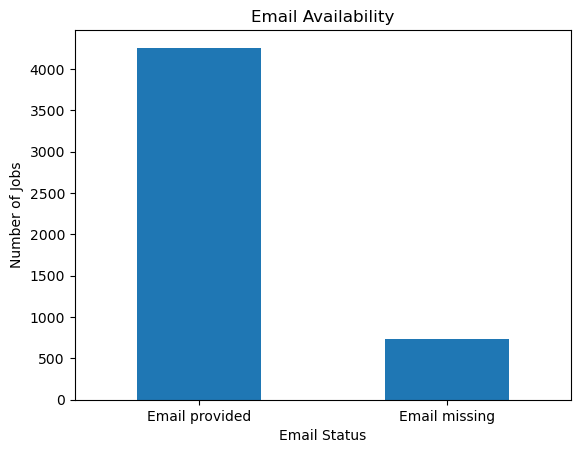

In [81]:
print('Rows:', len(df2))

print('\nFraud classes:')
print(df2['is_fraud'].value_counts().sort_index())

print('\nEmail status:')
email = df2['has_email'].map({
    True: 'Email provided',
    False: 'Email missing'
}).value_counts()

print(email)

email.plot(kind='bar')
plt.title('Email Availability')
plt.xlabel('Email Status')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=0)
plt.show()


### 17.15 Final EDA summary


In [82]:
print('EDA complete')
print('Rows:', len(model_df))
print('Columns:', len(model_df.columns))
print('Labeled:', model_df['is_fraud'].notna().sum())
print('Unlabeled:', model_df['is_fraud'].isna().sum())
print('Duplicate rows:', model_df.duplicated().sum())


EDA complete
Rows: 70302
Columns: 11
Labeled: 57150
Unlabeled: 13152
Duplicate rows: 0


# Modelling
1. Define Target
2. Carve Out Real-Only Holdout
3. Build Model Data
4. Train / Validation / Test Split
5. NLP Text Preprocessing
6. Text Feature Engineering
7. Structured Feature Engineering
8. Baseline Models
9. Class Imbalance Handling
10. Hybrid NLP Model
11. Model Comparison
12. Hyperparameter Tuning
13. Probability Analysis
14. Final Evaluation
15. Error Analysis
16. Model Interpretability
17. Select Final Model
18. Save Model Pipeline
19. Real Holdout Validation
20. Modelling Report

In [83]:
# Modelling dataset
nlp_df = model_df.copy()

The modelling flow moves from a text-only baseline to a hybrid model combining raw text and numeric signals. Logistic Regression and LinearSVC are trained, tuned, and evaluated with validation data before the single final holdout evaluation.

## Define Target

In [84]:
# Define Target
target = "is_fraud"

binary_target = "is_fraud_binary"

binary_map = {0: 0,1: 1, 2: 1}

class_names = {0: "Legitimate", 1: "Fraud-risk"}

In [85]:
# Create the binary target
nlp_df[binary_target] = nlp_df[target].map(binary_map)

# Verify the mapping
pd.crosstab(nlp_df['is_fraud'], nlp_df['is_fraud_binary'], dropna=False)

is_fraud_binary,0.0,1.0,NaN
is_fraud,,,
0.0,39219,0,0
1.0,0,11426,0
2.0,0,6505,0
NaN,0,0,13152


## CARVE OUT REAL-ONLY HOLDOUT

EMSCAD gives you genuine labels, whereas your synthetic dataset was generated. So don't randomly mix everything and report only one test-set score. The model can potentially learn characteristics of your synthetic generator and appear much better than it really is.

In [86]:
# Separate labelled and unalabelled data
# Labelled data for modelling
labelled_df = nlp_df[
    nlp_df["is_fraud_binary"].notna()
].copy()

# Unlabelled Kenya job postings for later prediction
unlabelled_df = nlp_df[
    nlp_df["is_fraud_binary"].isna()
].copy()

print("Labelled data:", labelled_df.shape)
print("Unlabelled data:", unlabelled_df.shape)

Labelled data: (57150, 12)
Unlabelled data: (13152, 12)


In [87]:
# Create binary target in final_df
# Use final_df since model_df no longer contains source_platform to only ideentify real/synthetic records
final_df["is_fraud_binary"] = final_df["is_fraud"].map({
    0: 0,   # Legitimate
    1: 1,   # Suspicious → Fraud-risk
    2: 1    # Fraudulent → Fraud-risk
})

In [88]:
# Identify labeller real-world data
real_labelled = final_df[
    (final_df["source_platform"] == "Fake Job Postings Dataset") &
    (final_df["is_fraud_binary"].notna())
].copy()

real_labelled["is_fraud_binary"].value_counts()

is_fraud_binary
0.0    16565
1.0      852
Name: count, dtype: int64

In [ ]:
import hashlib
import re

import pandas as pd
from sklearn.model_selection import train_test_split


RANDOM_STATE = 42

# Replace merged_labelled_df with the DataFrame used by the old split cell.
SOURCE_DF = final_df.copy()

TARGET_COLUMN = "is_fraud"
TEXT_COLUMNS = ["title", "description", "requirements"]


def normalize_posting_text(row):
    """Normalize title, description and requirements for duplicate detection."""
    parts = []

    for column in TEXT_COLUMNS:
        if column in row.index and pd.notna(row[column]):
            parts.append(str(row[column]))

    text = " ".join(parts).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def fingerprint_posting(row):
    """Return a stable hash for a normalized job posting."""
    normalized_text = normalize_posting_text(row)

    return hashlib.md5(
        normalized_text.encode("utf-8")
    ).hexdigest()


# ------------------------------------------------------------
# 1. Keep labelled rows only
# ------------------------------------------------------------

split_source = SOURCE_DF[
    SOURCE_DF[TARGET_COLUMN].notna()
].copy()


# Convert the original three classes into the binary modelling target:
# 0 = legitimate
# 1 = suspicious or fraudulent
split_source["fraud_risk"] = (
    split_source[TARGET_COLUMN].astype(int) != 0
).astype(int)


# ------------------------------------------------------------
# 2. Separate real and synthetic data before splitting
# ------------------------------------------------------------

if "is_synthetic" in split_source.columns:
    synthetic_mask = (
        split_source["is_synthetic"]
        .fillna(False)
        .astype(bool)
    )

elif "data_source" in split_source.columns:
    synthetic_mask = (
        split_source["data_source"]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.contains("synthetic")
    )

elif "source_platform" in split_source.columns:
    synthetic_mask = (
        split_source["source_platform"]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.contains("synthetic")
    )

else:
    raise ValueError(
        "Cannot identify synthetic rows. Expected is_synthetic, "
        "data_source, or source_platform."
    )


real_labelled_df = split_source[~synthetic_mask].copy()
synthetic_training_df = split_source[synthetic_mask].copy()

print("Real labelled rows:", len(real_labelled_df))
print("Synthetic labelled rows:", len(synthetic_training_df))


# ------------------------------------------------------------
# 3. Fingerprint the real labelled records
# ------------------------------------------------------------

real_labelled_df["fingerprint"] = real_labelled_df.apply(
    fingerprint_posting,
    axis=1,
)


# ------------------------------------------------------------
# 4. Remove duplicate families with contradictory labels
# ------------------------------------------------------------

labels_per_fingerprint = (
    real_labelled_df
    .groupby("fingerprint")["fraud_risk"]
    .nunique()
)

conflicting_fingerprints = set(
    labels_per_fingerprint[
        labels_per_fingerprint > 1
    ].index
)

print(
    "Conflicting-label fingerprints removed:",
    len(conflicting_fingerprints),
)

real_labelled_df = real_labelled_df[
    ~real_labelled_df["fingerprint"].isin(
        conflicting_fingerprints
    )
].copy()


# ------------------------------------------------------------
# 5. Keep one representative per fingerprint
# ------------------------------------------------------------

before_deduplication = len(real_labelled_df)

real_labelled_df = (
    real_labelled_df
    .drop_duplicates(
        subset="fingerprint",
        keep="first",
    )
    .reset_index(drop=True)
)

print(
    "Duplicate real rows removed:",
    before_deduplication - len(real_labelled_df),
)

print(
    "Real rows after deduplication:",
    len(real_labelled_df),
)

print(
    real_labelled_df["fraud_risk"]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# 6. Create the untouched real holdout
# ------------------------------------------------------------

real_development_df, real_holdout = train_test_split(
    real_labelled_df,
    test_size=0.20,
    stratify=real_labelled_df["fraud_risk"],
    random_state=RANDOM_STATE,
)


# ------------------------------------------------------------
# 7. Split the remaining real data into train and validation
# ------------------------------------------------------------

real_train_df, real_validation_df = train_test_split(
    real_development_df,
    test_size=0.20,
    stratify=real_development_df["fraud_risk"],
    random_state=RANDOM_STATE,
)


# ------------------------------------------------------------
# 8. Prepare synthetic records for training only
# ------------------------------------------------------------

synthetic_training_df["fingerprint"] = (
    synthetic_training_df.apply(
        fingerprint_posting,
        axis=1,
    )
)

synthetic_training_df = (
    synthetic_training_df
    .drop_duplicates(
        subset="fingerprint",
        keep="first",
    )
    .reset_index(drop=True)
)


# Do not allow synthetic copies of real postings into training.
real_reference_fingerprints = set(
    real_labelled_df["fingerprint"]
)

synthetic_training_df = synthetic_training_df[
    ~synthetic_training_df["fingerprint"].isin(
        real_reference_fingerprints
    )
].copy()


# ------------------------------------------------------------
# 9. Build the synthetic-assisted training pool
# ------------------------------------------------------------

training_pool = pd.concat(
    [
        real_train_df,
        synthetic_training_df,
    ],
    ignore_index=True,
)


# ------------------------------------------------------------
# 10. Prove that all partitions are isolated
# ------------------------------------------------------------

train_fingerprints = set(
    training_pool["fingerprint"]
)

validation_fingerprints = set(
    real_validation_df["fingerprint"]
)

holdout_fingerprints = set(
    real_holdout["fingerprint"]
)


assert not train_fingerprints & validation_fingerprints, (
    "Training and validation contamination detected"
)

assert not train_fingerprints & holdout_fingerprints, (
    "Training and holdout contamination detected"
)

assert not validation_fingerprints & holdout_fingerprints, (
    "Validation and holdout contamination detected"
)


print("\nFingerprint isolation passed.")
print("Real training rows:", len(real_train_df))
print("Synthetic training rows:", len(synthetic_training_df))
print("Combined training rows:", len(training_pool))
print("Real validation rows:", len(real_validation_df))
print("Untouched real holdout rows:", len(real_holdout))

Real labelled rows: 17417
Synthetic labelled rows: 39733


In [ ]:
# The corrected split cell already created the synthetic-assisted
# training pool. Do not concatenate the synthetic rows again.

print("Training pool already prepared")
print("Real training rows:", len(real_train_df))
print("Synthetic training rows:", len(synthetic_training_df))
print("Combined training rows:", len(training_pool))
print("Real validation rows:", len(real_validation_df))
print("Untouched real holdout rows:", len(real_holdout))

print("\nTraining target distribution:")
print(
    training_pool["fraud_risk"]
    .value_counts()
    .sort_index()
)

Training pool already prepared
Real training rows: 9955
Synthetic training rows: 39432
Combined training rows: 49387
Real validation rows: 2489
Untouched real holdout rows: 3111

Training target distribution:
fraud_risk
0    32182
1    17205
Name: count, dtype: int64


In [ ]:
# Compatibility aliases for the existing modelling workflow.
# The rest of the notebook should use these corrected partitions.

model_train = training_pool.copy()
model_validation = real_validation_df.copy()
model_holdout = real_holdout.copy()
TARGET_COLUMN = "fraud_risk"
print("model_train:", model_train.shape)
print("model_validation:", model_validation.shape)
print("model_holdout:", model_holdout.shape)

model_train: (49387, 17)
model_validation: (2489, 17)
model_holdout: (3111, 17)


In [ ]:
TEXT_COLUMNS = [
    "title",
    "description",
    "requirements",
]


def build_model_text(df):
    """Join the text fields consistently for every partition."""

    available_columns = [
        column
        for column in TEXT_COLUMNS
        if column in df.columns
    ]

    return (
        df[available_columns]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


model_train["combined_text"] = build_model_text(
    model_train
)

model_validation["combined_text"] = build_model_text(
    model_validation
)

model_holdout["combined_text"] = build_model_text(
    model_holdout
)


print(
    "Training text rows:",
    len(model_train["combined_text"]),
)

print(
    "Validation text rows:",
    len(model_validation["combined_text"]),
)

print(
    "Holdout text rows:",
    len(model_holdout["combined_text"]),
)

Training text rows: 49387
Validation text rows: 2489
Holdout text rows: 3111


## Corrected Modelling Data Flow

The notebook uses the clean fingerprint-isolated partitions created before modelling. Training data includes the development pool, real validation remains separate, and the real holdout is reserved for the single final evaluation below.


In [ ]:
# Use the corrected, fingerprint-isolated partitions.
# Training may include synthetic records, while validation and holdout remain
# real-only so model selection measures generalization to real postings.

TEXT_COLUMNS = ["title", "description", "requirements"]


def add_combined_text(frame):
    """Create the raw-text input expected by the deployed model pipeline."""
    result = frame.copy()

    available_columns = [
        column
        for column in TEXT_COLUMNS
        if column in result.columns
    ]

    if not available_columns:
        raise ValueError(
            "No modelling text columns were found. Expected at least "
            "title, description, or requirements."
        )

    result["combined_text"] = (
        result[available_columns]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    return result


model_train = add_combined_text(training_pool)
model_validation = add_combined_text(real_validation_df)
model_holdout = add_combined_text(real_holdout)


# Prove that the partitions remain isolated before modelling.
train_fingerprints = set(model_train["fingerprint"])
validation_fingerprints = set(model_validation["fingerprint"])
holdout_fingerprints = set(model_holdout["fingerprint"])

assert not train_fingerprints & validation_fingerprints, (
    "Training and validation contamination detected"
)

assert not train_fingerprints & holdout_fingerprints, (
    "Training and holdout contamination detected"
)

assert not validation_fingerprints & holdout_fingerprints, (
    "Validation and holdout contamination detected"
)


# Extract raw text and labels for modelling.
X_train_text = model_train["combined_text"]
X_validation_text = model_validation["combined_text"]
X_holdout_text = model_holdout["combined_text"]

y_train = model_train["fraud_risk"].astype(int)
y_validation = model_validation["fraud_risk"].astype(int)
y_holdout = model_holdout["fraud_risk"].astype(int)


# Basic input checks.
assert X_train_text.str.len().gt(0).all()
assert X_validation_text.str.len().gt(0).all()
assert X_holdout_text.str.len().gt(0).all()


print("Clean modelling checkpoint passed.")
print()
print("Training rows:", len(X_train_text))
print("Real validation rows:", len(X_validation_text))
print("Real holdout rows:", len(X_holdout_text))
print()
print("Text columns used:", [
    column
    for column in TEXT_COLUMNS
    if column in model_train.columns
])
print()
print("Training labels:")
print(y_train.value_counts().sort_index())
print()
print("Real validation labels:")
print(y_validation.value_counts().sort_index())
print()
print("Real holdout labels:")
print(y_holdout.value_counts().sort_index())


Clean modelling checkpoint passed.

Training rows: 49387
Real validation rows: 2489
Real holdout rows: 3111

Text columns used: ['title', 'description', 'requirements']

Training labels:
fraud_risk
0    32182
1    17205
Name: count, dtype: int64

Real validation labels:
fraud_risk
0    2382
1     107
Name: count, dtype: int64

Real holdout labels:
fraud_risk
0    2978
1     133
Name: count, dtype: int64


## Clean Development Flow

Training and validation use only the fingerprint-isolated development partitions. The real holdout is not transformed or scored until the final evaluation below.


In [ ]:
from pathlib import Path
import sys

# Locate the repository root whether the kernel starts in notebooks/
# or at the project root.
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(
        "Repository root could not be located. Start the notebook from the "
        "job-scam-detection repository."
    )

project_root_string = str(PROJECT_ROOT.resolve())

if project_root_string not in sys.path:
    sys.path.insert(0, project_root_string)

from src.models.feature_builder import TextFeatureBuilder

print(f"Project root: {PROJECT_ROOT.resolve()}")
print("TextFeatureBuilder imported successfully.")

RuntimeError: Repository root could not be located. Start the notebook from the job-scam-detection repository.

In [ ]:
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

from src.models.feature_builder import TextFeatureBuilder

assert not set(training_pool["fingerprint"]) & set(real_validation_df["fingerprint"])
assert not set(training_pool["fingerprint"]) & set(real_holdout["fingerprint"])
assert not set(real_validation_df["fingerprint"]) & set(real_holdout["fingerprint"])

print("Clean modelling checkpoint confirmed.")
print("X_train_text:", X_train_text.shape)
print("X_validation_text:", X_validation_text.shape)
print("X_holdout_text:", X_holdout_text.shape)

### Baseline Text Model

The following cells form the only modelling path used for the final model.
Training, validation and holdout partitions were isolated by normalized text
fingerprint before any vectorizer, scaler or classifier was fitted.

`class_weight='balanced'` gives the minority Fraud-risk class more influence
during fitting without changing the original class distribution or creating
synthetic copies inside the holdout.

In [ ]:
tfidf_baseline = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000,
)

X_train_tfidf = tfidf_baseline.fit_transform(X_train_text)
X_validation_tfidf = tfidf_baseline.transform(X_validation_text)

baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
)
baseline_model.fit(X_train_tfidf, y_train)

baseline_validation_proba = baseline_model.predict_proba(X_validation_tfidf)[:, 1]
baseline_validation_pred = (baseline_validation_proba >= 0.5).astype(int)

print(classification_report(
    y_validation,
    baseline_validation_pred,
    target_names=["Legitimate", "Fraud-risk"],
))
print("Baseline validation ROC-AUC:", round(
    roc_auc_score(y_validation, baseline_validation_proba), 4
))
print("Baseline validation PR-AUC:", round(
    average_precision_score(y_validation, baseline_validation_proba), 4
))

### Hybrid Feature Construction

The hybrid model adds six numeric signals calculated internally from the same raw text. No posting columns or missing-field indicators are required, so the training interface matches the deployed `TextFeatureBuilder` interface.

In [ ]:
numeric_builder = TextFeatureBuilder()

tfidf_hybrid = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000,
)
scaler_hybrid = StandardScaler()

X_train_hybrid_text = tfidf_hybrid.fit_transform(X_train_text)
X_validation_hybrid_text = tfidf_hybrid.transform(X_validation_text)

X_train_hybrid_numeric = scaler_hybrid.fit_transform(
    numeric_builder._numeric_features(X_train_text)
)
X_validation_hybrid_numeric = scaler_hybrid.transform(
    numeric_builder._numeric_features(X_validation_text)
)

X_train_hybrid = hstack([
    X_train_hybrid_text,
    X_train_hybrid_numeric,
]).tocsr()
X_validation_hybrid = hstack([
    X_validation_hybrid_text,
    X_validation_hybrid_numeric,
]).tocsr()

print("Hybrid training matrix:", X_train_hybrid.shape)
print("Hybrid validation matrix:", X_validation_hybrid.shape)

In [ ]:
hybrid_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
)
hybrid_lr.fit(X_train_hybrid, y_train)

hybrid_svm = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=3000,
)
hybrid_svm.fit(X_train_hybrid, y_train)

hybrid_lr_validation_proba = hybrid_lr.predict_proba(
    X_validation_hybrid
)[:, 1]
hybrid_svm_validation_score = hybrid_svm.decision_function(
    X_validation_hybrid
)

print("Hybrid Logistic Regression validation PR-AUC:", round(
    average_precision_score(y_validation, hybrid_lr_validation_proba), 4
))
print("Hybrid LinearSVC validation PR-AUC:", round(
    average_precision_score(y_validation, hybrid_svm_validation_score), 4
))

### Model Comparison

The comparison table uses validation data only. LinearSVC is compared with decision scores, not probabilities. Logistic Regression is the deployment candidate because it provides probabilities for thresholding and risk ranking, while remaining interpretable and compatible with sparse text.

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "TF-IDF Logistic Regression",
        "Hybrid Logistic Regression",
        "Hybrid LinearSVC",
    ],
    "Accuracy": [
        accuracy_score(y_validation, baseline_validation_pred),
        accuracy_score(y_validation, hybrid_lr.predict(X_validation_hybrid)),
        accuracy_score(y_validation, hybrid_svm.predict(X_validation_hybrid)),
    ],
    "Precision": [
        precision_score(y_validation, baseline_validation_pred),
        precision_score(y_validation, hybrid_lr.predict(X_validation_hybrid)),
        precision_score(y_validation, hybrid_svm.predict(X_validation_hybrid)),
    ],
    "Recall": [
        recall_score(y_validation, baseline_validation_pred),
        recall_score(y_validation, hybrid_lr.predict(X_validation_hybrid)),
        recall_score(y_validation, hybrid_svm.predict(X_validation_hybrid)),
    ],
    "F1": [
        f1_score(y_validation, baseline_validation_pred),
        f1_score(y_validation, hybrid_lr.predict(X_validation_hybrid)),
        f1_score(y_validation, hybrid_svm.predict(X_validation_hybrid)),
    ],
    "ROC-AUC": [
        roc_auc_score(y_validation, baseline_validation_proba),
        roc_auc_score(y_validation, hybrid_lr_validation_proba),
        roc_auc_score(y_validation, hybrid_svm_validation_score),
    ],
    "PR-AUC": [
        average_precision_score(y_validation, baseline_validation_proba),
        average_precision_score(y_validation, hybrid_lr_validation_proba),
        average_precision_score(y_validation, hybrid_svm_validation_score),
    ],
})

model_comparison.round(4)

### Training-Only Hyperparameter Tuning

GridSearchCV is restricted to `X_train_hybrid` and `y_train`. It uses average precision because the fraud-risk class is less frequent, and it never sees the real validation or holdout rows.

In [ ]:
svm_grid = GridSearchCV(
    LinearSVC(class_weight="balanced", random_state=42, max_iter=3000),
    {"C": [0.01, 0.1, 1, 10]},
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
)
svm_grid.fit(X_train_hybrid, y_train)

lr_grid = GridSearchCV(
    LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
    ),
    {"C": [0.01, 0.1, 1, 10, 100]},
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
)
lr_grid.fit(X_train_hybrid, y_train)

best_svm = svm_grid.best_estimator_
best_lr = lr_grid.best_estimator_
print("Best LinearSVC parameters:", svm_grid.best_params_)
print("Best Logistic Regression parameters:", lr_grid.best_params_)
print("Best Logistic Regression CV PR-AUC:", round(lr_grid.best_score_, 4))

### Validation Threshold Selection

The threshold sweep changes the probability cutoff and records precision, recall, F1, false positives, and false negatives on real validation data. The default 0.5 is not automatically accepted because missing fraud is more harmful than an understandable increase in review alerts.

In [ ]:
validation_proba = best_lr.predict_proba(X_validation_hybrid)[:, 1]
validation_threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.05):
    predictions = (validation_proba >= threshold).astype(int)
    matrix = confusion_matrix(y_validation, predictions)
    validation_threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "precision": precision_score(y_validation, predictions, zero_division=0),
        "recall": recall_score(y_validation, predictions, zero_division=0),
        "F1": f1_score(y_validation, predictions, zero_division=0),
        "false_positives": int(matrix[0, 1]),
        "false_negatives": int(matrix[1, 0]),
    })

validation_threshold_table = pd.DataFrame(validation_threshold_rows)
best_threshold = float(
    validation_threshold_table.loc[
        validation_threshold_table["F1"].idxmax(), "threshold"
    ]
)

print("Validation threshold table:")
display(validation_threshold_table.round(4))
print("Selected validation threshold:", best_threshold)

### Final Development Fit

After model and threshold selection, the final Logistic Regression is refit on the combined training and validation partitions. The holdout remains untouched, and the final TF-IDF vocabulary and scaler are fitted only on this development data.

In [ ]:
X_development_text = pd.concat(
    [X_train_text, X_validation_text],
    ignore_index=True,
)
y_development = pd.concat(
    [y_train, y_validation],
    ignore_index=True,
)

final_tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000,
)
final_scaler = StandardScaler()
final_builder = TextFeatureBuilder()

X_development_text_features = final_tfidf.fit_transform(X_development_text)
X_development_numeric = final_scaler.fit_transform(
    final_builder._numeric_features(X_development_text)
)
X_development_hybrid = hstack([
    X_development_text_features,
    X_development_numeric,
]).tocsr()

final_model = LogisticRegression(
    C=best_lr.C,
    class_weight="balanced",
    max_iter=2000,
    random_state=42,
)
final_model.fit(X_development_hybrid, y_development)
final_threshold = best_threshold

print("Final development rows:", len(X_development_text))
print("Final threshold:", final_threshold)

## Final Evaluation

The real holdout is transformed and scored for the first time here. This primary evaluation reports the unbiased performance of the final model selected from training and validation.

In [ ]:
X_holdout_text_features = final_tfidf.transform(X_holdout_text)
X_holdout_numeric_final = final_scaler.transform(
    final_builder._numeric_features(X_holdout_text)
)
X_holdout_final = hstack([
    X_holdout_text_features,
    X_holdout_numeric_final,
]).tocsr()

final_holdout_proba = final_model.predict_proba(X_holdout_final)[:, 1]
final_holdout_pred = (final_holdout_proba >= final_threshold).astype(int)

final_report = classification_report(
    y_holdout,
    final_holdout_pred,
    target_names=["Legitimate", "Fraud-risk"],
    output_dict=True,
)
final_matrix = confusion_matrix(y_holdout, final_holdout_pred)
tn, fp, fn, tp = final_matrix.ravel()

print(classification_report(
    y_holdout,
    final_holdout_pred,
    target_names=["Legitimate", "Fraud-risk"],
))
print("Final holdout ROC-AUC:", round(
    roc_auc_score(y_holdout, final_holdout_proba), 4
))
print("Final holdout PR-AUC:", round(
    average_precision_score(y_holdout, final_holdout_proba), 4
))
print("Confusion matrix:")
print(final_matrix)
print({
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_positives": int(tp),
})

### Interpreting the Final Confusion Matrix

The confusion matrix reports how the tool behaves for a job seeker: true negatives are legitimate postings left unflagged, false positives are legitimate postings incorrectly warned about, false negatives are fraudulent postings missed, and true positives are fraudulent postings detected. False negatives matter most because a missed scam can lead to financial loss or stolen personal information. The real holdout result is more trustworthy than synthetic-heavy validation because it measures performance on unseen real EMSCAD postings.

### Post Hoc Holdout Threshold Diagnostic

Post hoc diagnostic only. These results were not used for model selection, training, tuning, or threshold selection. The sweep shows what recall would be achievable at lower thresholds and the precision cost on the final holdout. It is informative for future operating-point decisions, but it does not change the exported model.

In [ ]:
posthoc_threshold_rows = []
for threshold in [0.10, 0.20, 0.30, 0.40, final_threshold, 0.50, 0.60, 0.70]:
    predictions = (final_holdout_proba >= threshold).astype(int)
    matrix = confusion_matrix(y_holdout, predictions)
    posthoc_threshold_rows.append({
        "threshold": round(float(threshold), 3),
        "precision": precision_score(y_holdout, predictions, zero_division=0),
        "recall": recall_score(y_holdout, predictions, zero_division=0),
        "F1": f1_score(y_holdout, predictions, zero_division=0),
        "false_positives": int(matrix[0, 1]),
        "false_negatives": int(matrix[1, 0]),
    })

posthoc_threshold_table = pd.DataFrame(posthoc_threshold_rows)
display(posthoc_threshold_table.round(4))

### Coefficient Interpretation

Positive Logistic Regression coefficients push a posting toward Fraud-risk, while negative coefficients push it toward Legitimate. Terms such as `group looking`, `needed`, `weather`, or `shared confirm` may be synthetic generator fragments rather than validated real-world scam language. The deterministic API rules provide the actionable signals, such as upfront fees, mobile money requests, passport retention, and no interview.

In [ ]:
tfidf_feature_names = final_tfidf.get_feature_names_out()
all_feature_names = list(tfidf_feature_names) + list(
    TextFeatureBuilder.NUMERIC_COLUMNS
)
coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": final_model.coef_[0],
})

top_fraud_features = coef_df.sort_values(
    "coefficient", ascending=False
).head(20)

top_fraud_features

### Pipeline Export

The exported artifact is one sklearn Pipeline containing the fitted raw-text feature transformer, its TF-IDF vectorizer and scaler, and the final Logistic Regression classifier. It accepts a single raw text string, so the API does not need to reconstruct structured columns.

In [ ]:
from pathlib import Path
import joblib
from sklearn.pipeline import Pipeline

pipeline_feature_builder = TextFeatureBuilder()
pipeline_feature_builder.tfidf_ = final_tfidf
pipeline_feature_builder.scaler_ = final_scaler

inference_pipeline = Pipeline([
    ("features", pipeline_feature_builder),
    ("classifier", final_model),
])
inference_pipeline.version_ = "logreg-hybrid-v3-clean-split"

scam_text = (
    "Immediate job opportunity. Send a mobile money registration fee today "
    "to secure your position. No interview required."
)
legitimate_text = (
    "Permanent analyst role with a written contract, formal interview, "
    "published company address, and standard employment benefits."
)

scam_score = inference_pipeline.predict_proba([scam_text])[:, 1][0]
legitimate_score = inference_pipeline.predict_proba([legitimate_text])[:, 1][0]

assert 0 <= scam_score <= 1
assert 0 <= legitimate_score <= 1
assert scam_score > legitimate_score

artifact_path = PROJECT_ROOT / "artifacts" / "model.pkl"
artifact_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(inference_pipeline, artifact_path)

reloaded_pipeline = joblib.load(artifact_path)
reloaded_scores = reloaded_pipeline.predict_proba([
    scam_text,
    legitimate_text,
])[:, 1]

assert abs(reloaded_scores[0] - scam_score) < 1e-12
assert abs(reloaded_scores[1] - legitimate_score) < 1e-12

print("Pipeline version:", inference_pipeline.version_)
print("Scam-style score:", round(scam_score, 6))
print("Legitimate-style score:", round(legitimate_score, 6))
print("Saved and reloaded:", artifact_path)

## 20. Modelling Report

### Corrected Data Flow

The notebook uses fingerprint-isolated partitions created before modelling: `training_pool` contains real training and synthetic training records, `real_validation_df` contains real validation records, and `real_holdout` contains untouched real EMSCAD records. The clean checkpoint asserts that no posting fingerprint appears in more than one partition. The old second split from `labelled_df`, the old structured matrices, and all pre-final holdout scoring cells were removed.

The merged dataset retains three classes for EDA. Before modelling, Suspicious and Fraudulent are combined into binary Fraud-risk, where `0` is Legitimate and `1` is Suspicious or Fraudulent.

### Models And Selection

The baseline TF-IDF Logistic Regression achieved validation ROC-AUC **0.9057** and PR-AUC **0.6199**. The corrected hybrid comparison achieved validation PR-AUC **0.5845** for Logistic Regression and **0.7386** for LinearSVC. LinearSVC ranked better on validation, but Logistic Regression was selected for the deployed artifact because it provides probabilities for thresholding and risk ranking and integrates directly with the raw-text pipeline.

GridSearchCV used training data only, with average precision as the scoring metric. The final Logistic Regression used the training-selected `C` value and was refit on the combined training and validation development data. The operating threshold was selected from real validation data, not from the holdout, and was **0.35**.9, 64]]`
- True negatives: **2,958**
- False positives: **20**
- False negatives: **69**
- True positives: **64**

The model catches 64 of 133 real Fraud-risk postings and misses 69. This is the honest real-world result and is substantially less reassuring than synthetic-heavy validation. For a job seeker, false negatives matter because a missed scam can lead to financial loss or stolen personal information.

### Post Hoc Threshold Diagnostic

The holdout sweep was run only after the primary evaluation. It was not used for model selection, training, tuning, or threshold selection. Lowering the threshold increases recall but creates more false alerts:

- Threshold `0.30`: recall **0.5865**, precision **0.7027**, 33 false positives, 55 false negatives.
- Threshold `0.20`: recall **0.7218**, precision **0.4800**, 104 false positives, 37 false negatives.
- Threshold `0.10`: recall **0.8496**, precision **0.2062**, 435 false positives, 20 false negatives.

A lower threshold may be appropriate for a warning and human-review workflow, but the next operating point should be selected on a future representative validation set, not tuned to this holdout.

### Interpretation And Scope

Coefficient terms such as `group looking`, `needed`, `weather`, or `shared confirm` can reflect synthetic generator templates rather than validated real-world scam language. The deterministic API rules provide actionable signals such as upfront fees, mobile money requests, passport retention, and no interview. Government registry verification, rule explanations, API routing, authentication, and dashboard behavior are implemented in the deployed application, not in this notebook.

### Limitations

- Training data is synthetic-heavy.
- No publicly available labelled Kenyan job-scam dataset was available for training and unbiased local evaluation.
- Synthetic template terms appear in the coefficients and must not be presented as proven scam indicators.
- Normalized near-duplicates were found during final review and fingerprint isolation was added to prevent them crossing partitions.
- Holdout contamination was found and corrected during final review. The cause was the old independent structured split from `labelled_df`, which allowed holdout-derived rows into hybrid preprocessing. The corrected flow uses `training_pool`, fits preprocessing on development data only, and evaluates the holdout once before post hoc diagnostics.
- Threshold choices trade fraud recall against false alerts.
- Kenya-specific performance remains uncertain until locally annotated data is available.

### Deployment

The notebook exports `artifacts/model.pkl` as one sklearn Pipeline, version `logreg-hybrid-v3-clean-split`. The pipeline accepts raw text through `predict_proba`, and the notebook verifies predictions before and after joblib reload.

